In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
df = pd.read_csv('/content/online_retail.csv')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
(df['Quantity'] <= 0).sum()

np.int64(10624)

In [10]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

Data Cleaning

In [11]:
df = df.dropna(subset=['CustomerID', 'Description'])

In [12]:
df.shape

(406829, 8)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df[df['Quantity'] > 0]

In [16]:
df = df[df['UnitPrice'] > 0]

In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [19]:
df['CustomerID'] = df['CustomerID'].astype(int)

Feature Engineering

In [20]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [22]:
df['Year'] = df['InvoiceDate'].dt.year

In [23]:
df['Month'] = df['InvoiceDate'].dt.month

In [24]:
df['Day'] = df['InvoiceDate'].dt.day

In [25]:
df.shape

(392692, 12)

Exploratory Data Analysis

In [26]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 8887208.89


In [27]:
total_customers = df['CustomerID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 4338


In [28]:
total_orders = df['InvoiceNo'].nunique()
print("Total Orders:", total_orders)

Total Orders: 18532


In [29]:
avg_order_value = df.groupby('InvoiceNo')['Revenue'].sum().mean()
print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 479.56


In [30]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue.head(10)

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


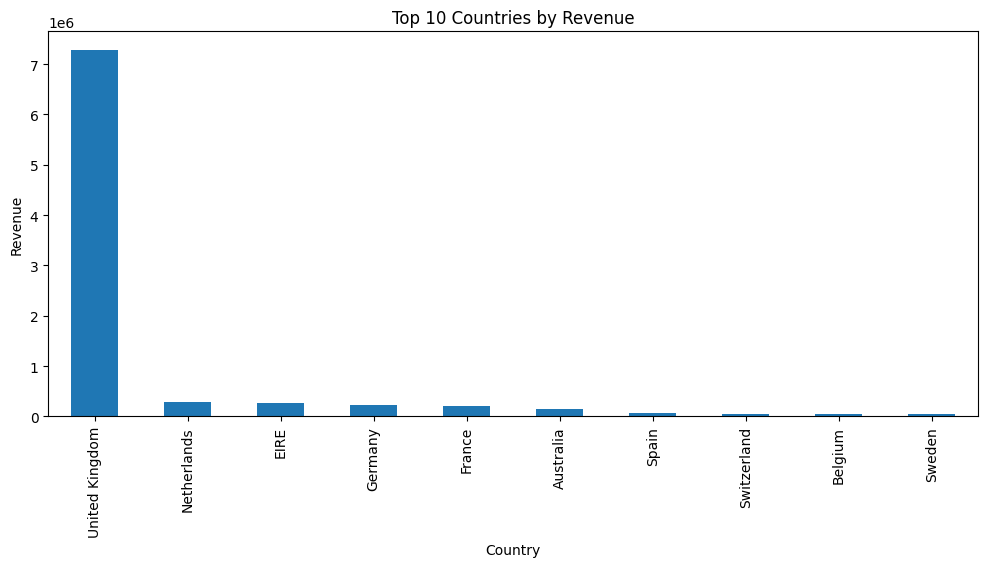

In [31]:
plt.figure(figsize=(12,5))
country_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue')
plt.show()

In [32]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
top_customers.head(10)

,Revenue
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


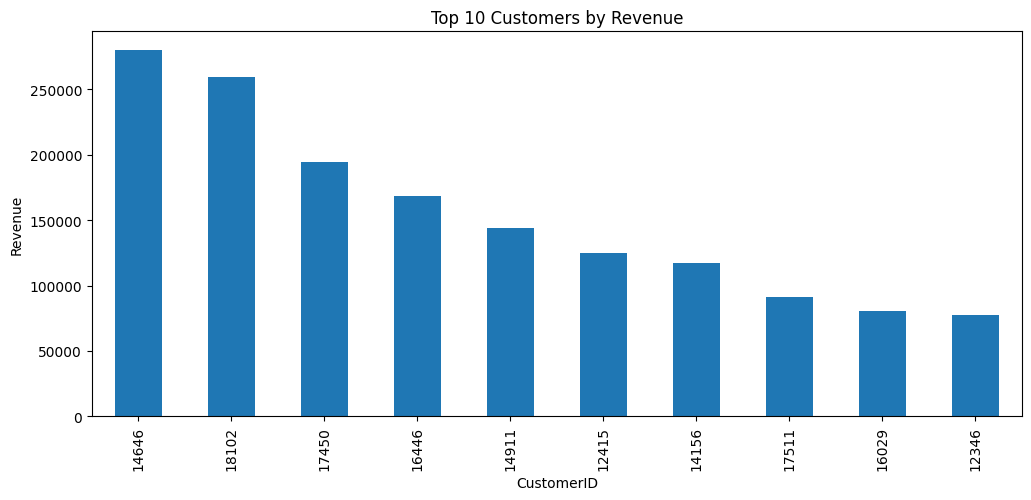

In [33]:
plt.figure(figsize=(12,5))
top_customers.head(10).plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.ylabel('Revenue')
plt.show()

In [34]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


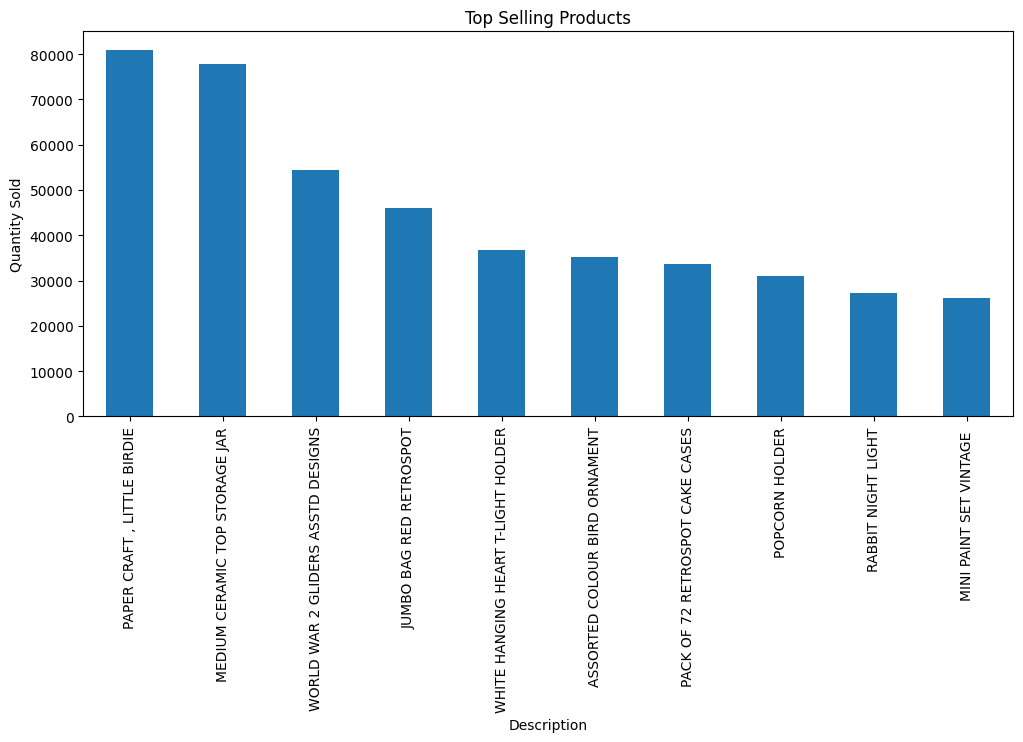

In [35]:
plt.figure(figsize=(12,5))
top_products.head(10).plot(kind='bar')
plt.title('Top Selling Products')
plt.ylabel('Quantity Sold')
plt.show()

In [36]:
monthly_sales = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly_sales

,Year,Month,Revenue
0,2010,12,570422.730
1,2011,1,568101.310
2,2011,2,446084.920
3,2011,3,594081.760
4,2011,4,468374.331
5,2011,5,677355.150
6,2011,6,660046.050
7,2011,7,598962.901
8,2011,8,644051.040
9,2011,9,950690.202


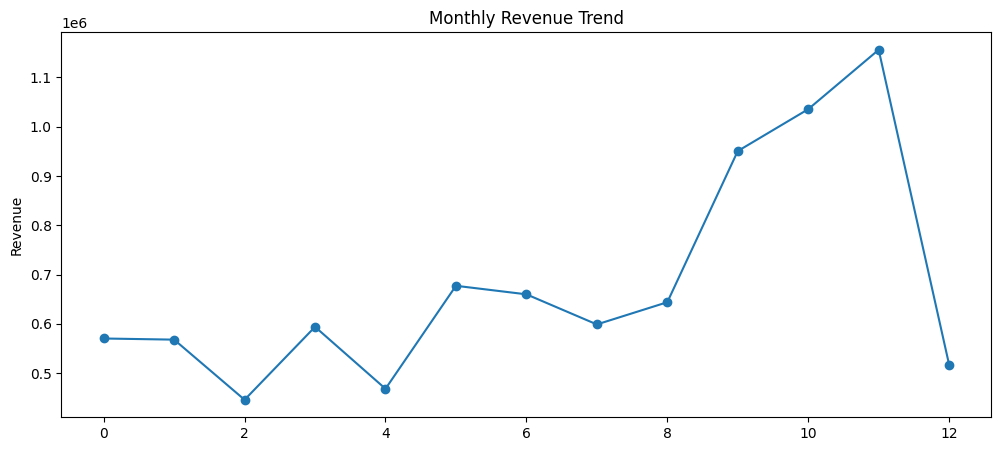

In [37]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales['Revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.show()

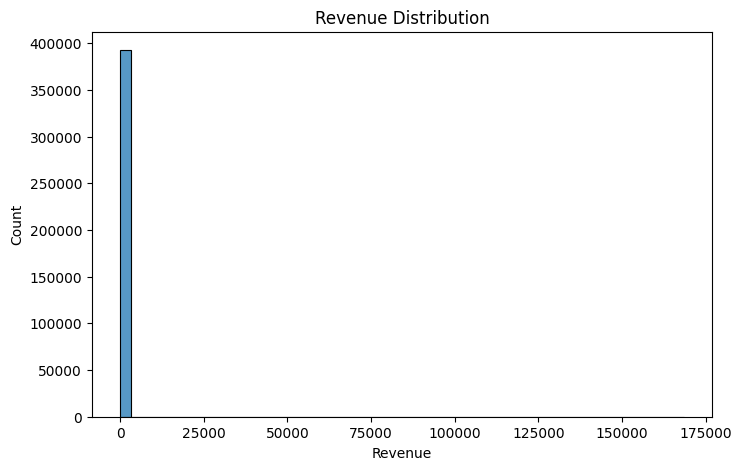

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Revenue'], bins=50)
plt.title('Revenue Distribution')
plt.show()

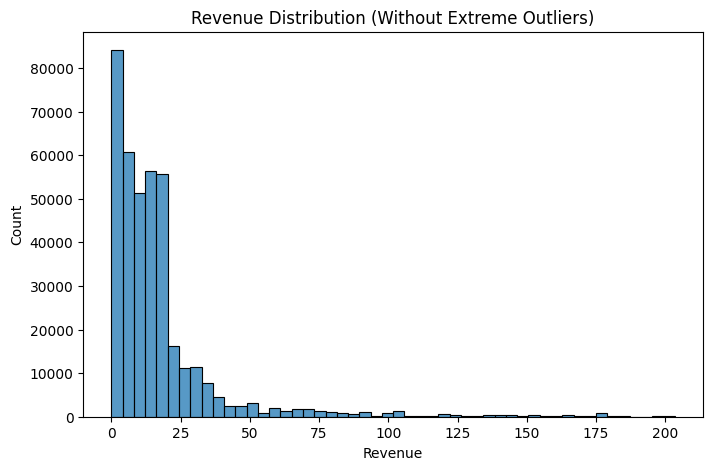

In [39]:
revenue_99 = df['Revenue'].quantile(0.99)

plt.figure(figsize=(8,5))
sns.histplot(df[df['Revenue'] <= revenue_99]['Revenue'], bins=50)
plt.title('Revenue Distribution (Without Extreme Outliers)')
plt.show()

RFM Analysis

In [40]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [41]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [42]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [43]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [44]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [45]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [46]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [47]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [48]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


In [53]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4:
        return 'Champions'

    elif r >= 3 and f >= 3:
        return 'Loyal Customers'

    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'

    elif r <= 2 and f >= 3:
        return 'At Risk'

    elif r == 1 and f <= 2:
        return 'Lost Customers'

    else:
        return 'Need Attention'

In [54]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [55]:
rfm['Segment'].value_counts()

,count
Segment,
Loyal Customers,914
Lost Customers,903
Potential Loyalists,665
At Risk,646
Champions,609
Need Attention,601


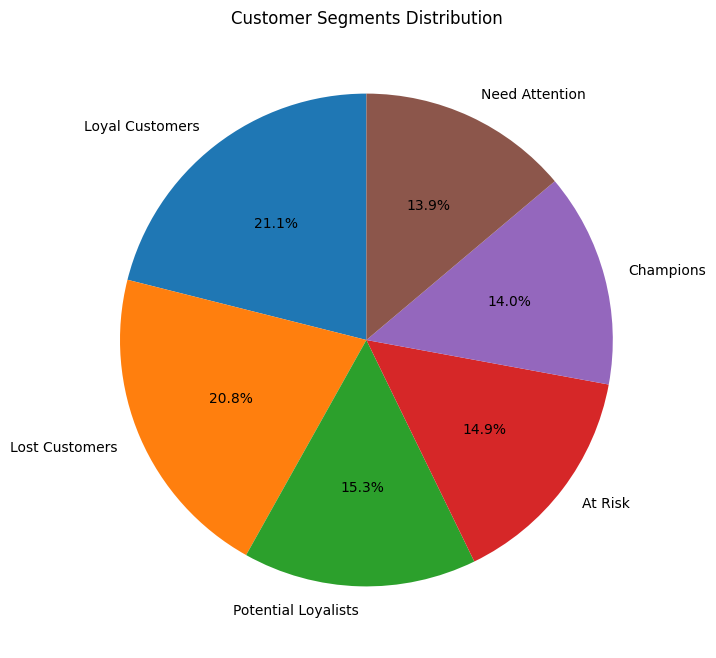

In [56]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(segment_counts,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Customer Segments Distribution')
plt.show()

CLV Calculation

In [59]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()

clv = pd.DataFrame({
    'Total_Revenue': customer_revenue,
    'Orders': customer_orders
})

In [60]:
clv['Avg_Order_Value'] = clv['Total_Revenue'] / clv['Orders']
clv['CLV'] = clv['Avg_Order_Value'] * clv['Orders']

In [61]:
clv.head()

,Total_Revenue,Orders,Avg_Order_Value,CLV
CustomerID,,,,
12346,77183.60,1,77183.600000,77183.60
12347,4310.00,7,615.714286,4310.00
12348,1797.24,4,449.310000,1797.24
12349,1757.55,1,1757.550000,1757.55
12350,334.40,1,334.400000,334.40


In [62]:
rfm = rfm.merge(clv[['CLV']], left_index=True, right_index=True)

In [63]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV
CustomerID,,,,,,,,,
12346,326,1,77183.60,1,1,4,114,Lost Customers,77183.60
12347,2,7,4310.00,4,4,4,444,Champions,4310.00
12348,75,4,1797.24,2,3,4,234,At Risk,1797.24
12349,19,1,1757.55,3,1,4,314,Potential Loyalists,1757.55
12350,310,1,334.40,1,1,2,112,Lost Customers,334.40


In [64]:
rfm['CLV_Category'] = pd.qcut(
    rfm['CLV'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

In [65]:
rfm['CLV_Category'].value_counts()

,count
CLV_Category,
Low Value,1446
Medium Value,1446
High Value,1446


In [66]:
high_risk = rfm[
    (rfm['CLV_Category'] == 'High Value') &
    (rfm['Segment'].isin(['At Risk', 'Lost Customers']))
]

high_risk.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV,CLV_Category
CustomerID,,,,,,,,,,
12346,326,1,77183.60,1,1,4,114,Lost Customers,77183.60,High Value
12348,75,4,1797.24,2,3,4,234,At Risk,1797.24,High Value
12359,58,4,6310.03,2,3,4,234,At Risk,6310.03,High Value
12360,52,3,2662.06,2,3,4,234,At Risk,2662.06,High Value
12372,72,3,1298.04,2,3,3,233,At Risk,1298.04,High Value
12377,315,2,1628.12,1,2,3,123,Lost Customers,1628.12,High Value
12383,185,5,1850.56,1,3,4,134,At Risk,1850.56,High Value
12393,72,4,1582.60,2,3,3,233,At Risk,1582.60,High Value
12405,149,1,1710.39,1,1,4,114,Lost Customers,1710.39,High Value


Churn Label Creation

In [67]:
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

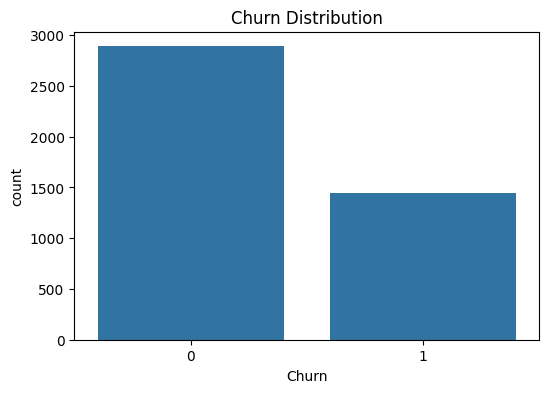

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=rfm)
plt.title('Churn Distribution')
plt.show()

In [69]:
X = rfm[['Recency', 'Frequency', 'Monetary', 'CLV']]
y = rfm['Churn']

In [70]:
X.head()

,Recency,Frequency,Monetary,CLV
CustomerID,,,,
12346,326,1,77183.60,77183.60
12347,2,7,4310.00,4310.00
12348,75,4,1797.24,1797.24
12349,19,1,1757.55,1757.55
12350,310,1,334.40,334.40


Train Test Split

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [72]:
print(X_train.shape)
print(X_test.shape)

(3470, 4)
(868, 4)


Feature Scaling

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [75]:
y_pred = lr.predict(X_test_scaled)

In [76]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9919354838709677


In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       561
           1       1.00      0.98      0.99       307

    accuracy                           0.99       868
   macro avg       0.99      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



In [78]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[561,   0],
       [  7, 300]])

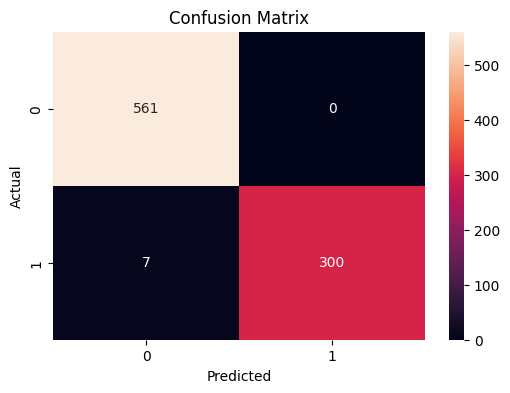

In [79]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [81]:
rf_pred = rf_model.predict(X_test)

In [82]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       561
           1       1.00      1.00      1.00       307

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [83]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

,0
Recency,0.925137
Frequency,0.051937
CLV,0.014605
Monetary,0.008321


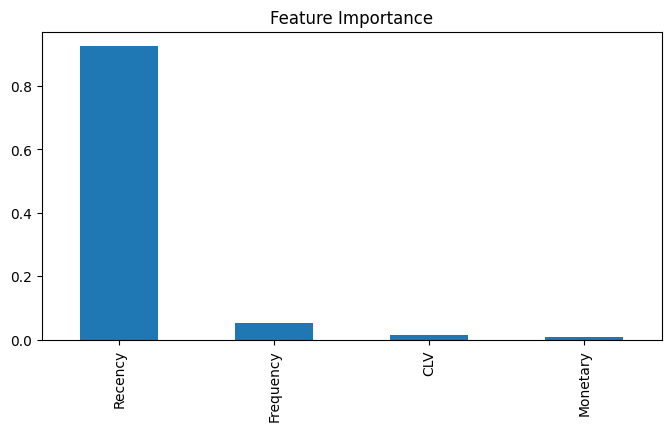

In [84]:
plt.figure(figsize=(8,4))
importance.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

**Revenue at Risk**

How much money may we lose if churned customers leave?

In [85]:
revenue_at_risk = rfm[rfm['Churn'] == 1]['CLV'].sum()
print("Revenue at Risk:", round(revenue_at_risk, 2))

Revenue at Risk: 1032542.29


In [86]:
high_value_churn = rfm[
    (rfm['Churn'] == 1) &
    (rfm['CLV_Category'] == 'High Value')
]

high_value_churn.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV,CLV_Category,Churn
CustomerID,,,,,,,,,,,
12346,326,1,77183.60,1,1,4,114,Lost Customers,77183.60,High Value,1
12377,315,2,1628.12,1,2,3,123,Lost Customers,1628.12,High Value,1
12378,130,1,4008.62,2,1,4,214,Need Attention,4008.62,High Value,1
12383,185,5,1850.56,1,3,4,134,At Risk,1850.56,High Value,1
12405,149,1,1710.39,1,1,4,114,Lost Customers,1710.39,High Value,1
12424,163,2,1760.96,1,2,4,124,Lost Customers,1760.96,High Value,1
12501,337,1,2169.39,1,1,4,114,Lost Customers,2169.39,High Value,1
12502,96,5,3723.87,2,3,4,234,At Risk,3723.87,High Value,1
12507,134,3,1304.81,2,3,3,233,At Risk,1304.81,High Value,1


In [87]:
rfm.to_csv("customer_churn_dashboard.csv")

In [88]:
from google.colab import files
files.download("customer_churn_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>